In [1]:
from pole import Pole, PolyRLAgent, Season
import matplotlib.pyplot as plt
from time import perf_counter
from tqdm import tqdm

In [2]:
pole = Pole(0.500, 0.100)

pole.dt = 0.01

agent = PolyRLAgent(
    eps=0.2,
    gamma=0.9,
    alpha=0.3,
    min_action=-0.02,
    max_action=0.02,
    action_variance=1,
)
agent.set_environment(pole)

season = Season(agent)

episodes_per_season = 400
season_inputs = {
    "eps":             [0.0, 0.2,  0.6, 0.9],
    "gamma":           [0.9, 0.9,  0.9, 0.9],
    "alpha":           [1.0, 1.0,  1.0, 1.0],
    "action_variance": [1.0, 0.8,  0.4, 0.1],
    "n_episodes":      [2000, 10000, 10000, 10000]
}

  0%|          | 0/4 [00:00<?, ?it/s]

dt 3.3844189110022853


<Figure size 432x288 with 0 Axes>

Text(0.5, 0.98, 'S0E0')

Text(0.5, 1.0, 'action')

...

Text(0.5, 1.0, 'delta_v')

Text(0.5, 1.0, 'reward')

Text(0.5, 1.0, 'theta')

Text(0.5, 1.0, 'theta_dot')

100%|██████████| 4/4 [05:56<00:00, 89.15s/it]


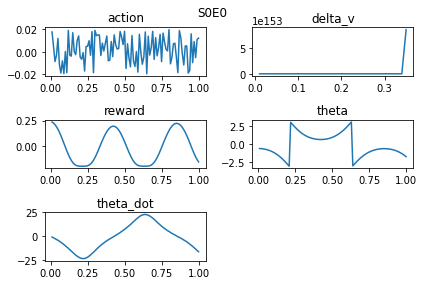

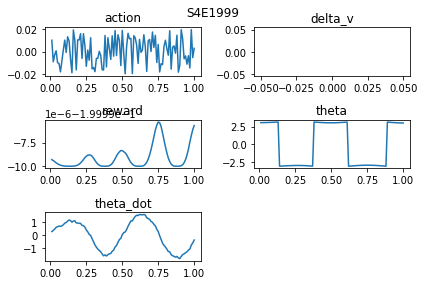

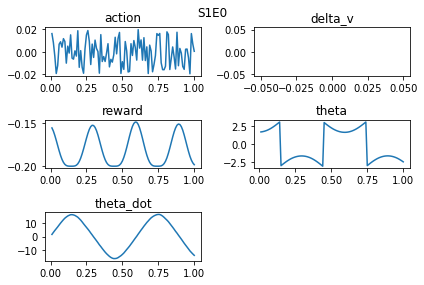

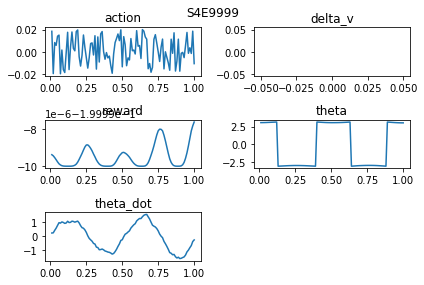

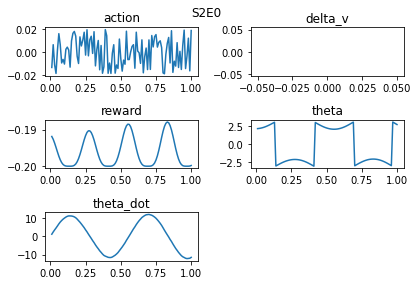

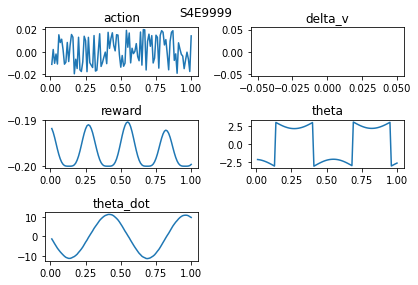

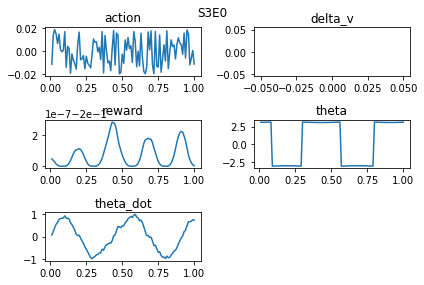

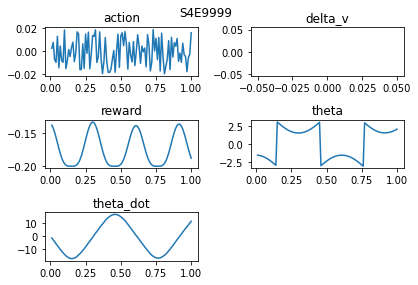

In [3]:
reward_sum = []
for i in tqdm(range(len(season_inputs["eps"]))):
    # Setup agent
    agent.eps = season_inputs["eps"][i]
    agent.gamma = season_inputs["gamma"][i]
    agent.alpha = season_inputs["alpha"][i]
    agent.action_variance = season_inputs["action_variance"][i]

    # Run season
    t0 = perf_counter()
    season.run(season_inputs["n_episodes"][i], 1, 100)
    print("dt", perf_counter() - t0)

    # Plot results
    season_data = season.get_data_log()
    for idx, episode_data in season_data.items():
        plt.figure();
        plt.suptitle(f"S{i}E{idx}");
        for i, value in enumerate(episode_data):
            plt.subplot(3, 2, i+1);
            plt.plot(episode_data.time, episode_data[value]);
            plt.title(value);

        plt.tight_layout();

    scalar_data = season.get_scalar_data()
    reward_sum.extend(scalar_data['reward_sum'])

In [ ]:
plt.figure()
plt.plot(reward_sum)
plt.title("Reward sum")
plt.show()
